In [1]:
#solve the low thrust optimization problem as an nlp 

#we want to be able to match this solution with the polynomial optimization methods

#here we are still using symplectic euler in the integrator and writing all the constraints
#in such a way that they can be written as a qcqp 
using Pkg
Pkg.activate(".")

  Activating project at `~/Research/polynomial_opt`


In [2]:
using Test 
using LinearAlgebra
using SparseArrays
using Plots
using ForwardDiff
import lazy_nlp_qd 

In [3]:
#sizes of all the states 
nq = 3
nv = 3
na = 3
nr = 1
ns = 1
nw = 1
nu = 3

3

In [4]:
#gravitational parameter for the Earth 
μ = 3.986004418e5 #km3/s2

398600.4418

In [5]:
#iss initial conditions
r0 = [6791.0; 0; 0] #km
v0 = [0; cosd(51.5)*7.66; sind(51.5)*7.66] #km/s
x_initial_0 = [r0; v0]

6-element Vector{Float64}:
 6791.0
    0.0
    0.0
    0.0
    4.768462116644166
    5.994778481489491

In [6]:
#finding the period
r_initial = norm(r0)

#for 1 rev
iss_period = 2*pi*sqrt(r_initial^3/μ)

5569.440597283014

In [7]:
#working for 1 rev ...
#revs = 1

#around 8 min solve time... (working)
#revs = 10

#revs for polynomial opt example (working) 4 second solve time 
revs = 10

#period 
#total period 
period = revs*iss_period 

55694.405972830136

In [8]:
#working with 10 rev horizon 
#knot_pts = 30

#course discretization that we try out in the polynomial opt example
#working with 5 rev horizon
knot_pts = 19

#number of knot points  
N=knot_pts*revs

190

In [9]:
#define a timestep
#in seconds 
h = period/(N-1) 

294.6793966816409

In [10]:
function two_body_dynamics(x)

    q = x[1:3]
    v = x[4:6]

    a = zeros(eltype(x), size(x))

    r = norm(q)
    
    a[1:3] = v

    a[4:6] = (-μ/r^3)*q

    return a

end

two_body_dynamics (generic function with 1 method)

In [11]:
#semi implicit euler 
function symplectic_euler(x)

    #the q and the v are already scaled 
    q = x[1:3]
    v = x[4:6]

    #next timestep
    xnext = zeros(6)

    #ak = two_body_dynamics(x)[4:6]
    ak = (-μ/(norm(q)^3))*q
    #ak = (-μ_scaled/(norm(q)^3))*q


    #explicit euler on the velocities
    #vk1
    xnext[4:6] = v + h*ak

    #implicit euler on the positions
    #qk1
    xnext[1:3] = q + h*xnext[4:6]

    return xnext 

end

symplectic_euler (generic function with 1 method)

In [12]:
#integrate the orbit with symplectic euler to see if it closes

xtraj = zeros(6, N)

xtraj[:,1] = x_initial_0


6-element Vector{Float64}:
 6791.0
    0.0
    0.0
    0.0
    4.768462116644166
    5.994778481489491

In [13]:
#integrate using symplectic Euler to generate an initial guess
for i=1:N-1

    xtraj[:,i+1] = symplectic_euler(xtraj[:,i])

end


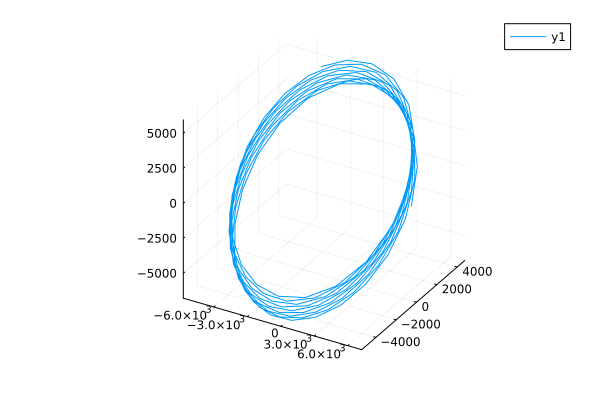

In [14]:
plot(xtraj[1,:], xtraj[2,:], xtraj[3,:])

In [15]:
period 

55694.405972830136

In [16]:
#going to scale position by semi major axis length 
position_scale = r_initial 

#scaled to make the period 1 
#time_scale = iss_period 
#works with 1
#thrust_limit_kN = 0.000432

#this works with 29% sub opt gap  (block structure)
#0.6% opt gap with MD structure 
#this is working...
#thrust_limit_kN = 0.00002

#2 Newtons 
#thrust_limit_kN = 0.002

#2 milliNewton
#thrust_limit_kN = 0.000002

thrust_limit_kN = 20e-9

#currently in the testing code
#this works 
#thrust_limit_kN = 2e-5

#scale to make the minimum control 1
#time_scale = sqrt(position_scale/thrust_limit_kN)

#scaled to make the period 1
time_scale = period 

velocity_scale = position_scale/time_scale

acceleration_scale = position_scale/time_scale^2

μ_scaled = μ/(position_scale^3/time_scale^2)

h_scaled = h/time_scale

u_max_bound = thrust_limit_kN/acceleration_scale 

0.009135228557403672

In [17]:
h_scaled 

0.005291005291005291

In [18]:
time_scale 

55694.405972830136

In [19]:
xtraj_scaled = [xtraj[1:3,:]./position_scale; xtraj[4:6,:]./velocity_scale]

6×190 Matrix{Float64}:
  1.0       0.889481    0.664144  …   -0.115677   -0.427906   -0.705643
  0.0       0.206916    0.387123       0.656082    0.638206    0.568885
  0.0       0.260129    0.48668        0.824808    0.802335    0.715186
  0.0     -20.8881    -42.5886       -61.0387    -59.0114    -52.4922
 39.1072   39.1072     34.059          8.11964    -3.37856   -13.1017
 49.1644   49.1644     42.8181    …   10.2078     -4.24743   -16.4711

In [20]:
#solve for a_traj_scaled
a_traj_scaled = zeros(3, N)


for i=1:N

    a_traj_scaled[:,i] = (-μ_scaled/(norm(xtraj_scaled[1:3, i])^3))*xtraj_scaled[1:3, i] 

end

In [21]:
a_traj_scaled 

3×190 Matrix{Float64}:
 -3947.84  -4101.41   -3481.18  -1922.55  …    383.159   1232.13   1809.98
    -0.0    -954.094  -2029.14  -2875.35     -2173.16   -1837.67  -1459.19
    -0.0   -1199.46   -2550.98  -3614.81     -2732.04   -2310.27  -1834.46

In [22]:
#updated for u and n variables in the ipopt projection problem

function create_idx(nq, nv, na, nr, nu, N)

    # This function creates some useful indexing tools for Z 
    # q_i = Z[idx.q[i]]
    # v_i = Z[idx.v[i]]
    # a_i = Z[idx.a[i]]
    # r_i = Z[idx.r[i]]
    # u_i = Z[idx.u[i]]

    #stacked up vector 
    # z = [all_q, all_v, all_a, all_r, all_u]

    #length of the entire stacked up vector 
    nz = (N*nq) + (N*nv) + (N*na) + N*(nr) + ((N-1)*nu) + (N*ns) + (N*nw)

    q = [(i-1)*(nq) .+ (1:nq) for i=1:N]

    v = [(i-1)*(nv) .+ (nq*N+1:nq*N+nv) for i=1:N]

    a = [(i-1)*(na) .+ (nq*N+ nv*N + 1:nq*N+ nv*N+na) for i=1:N]

    r = [(i-1)*(nr) .+ (nq*N+ nv*N + na*N +nr) for i=1:N]

    u = [(i-1)*(nu) .+ (nq*N+ nv*N + na*N + nr*N+1:nq*N+ nv*N + na*N + nr*N +nu) for i=1:N-1]

    s = [(i-1)*(ns) .+ (nq*N+ nv*N + na*N + nr*N + (N-1)*nu + ns) for i=1:N]

    w = [(i-1)*(nw) .+ (nq*N+ nv*N + na*N + nr*N +(N-1)*nu + N*ns + nw) for i=1:N]

    #total number of dynamics constraints 
    nd = (nq*(N-1)) + (nv*(N-1)) + (na*N)

    #position integrator constraint 
    cq = [(i-1)*(nq) .+ (1:nq) for i=1:N-1]

    #velocity integrator constraint 
    cv = [(i-1)*(nv) .+ ((nq*(N-1))+1:(nq*(N-1)) + nv) for i=1:N-1]

    #acceleration constraint at each knot point 
    ca = [(i-1)*(na) .+ ((nq*(N-1)) + (nv*(N-1))+1:(nq*(N-1)) +(nv*(N-1))+ na) for i=1:N]
    
    return (q=q,v=v,N=N,a=a,r=r, u= u, s=s, w=w, cq = cq, cv = cv, ca = ca, nd= nd, nz= nz)

end

create_idx (generic function with 1 method)

In [23]:
idx_1 = create_idx(nq, nv, na, nr, nu, N)

(q = UnitRange{Int64}[1:3, 4:6, 7:9, 10:12, 13:15, 16:18, 19:21, 22:24, 25:27, 28:30  …  541:543, 544:546, 547:549, 550:552, 553:555, 556:558, 559:561, 562:564, 565:567, 568:570], v = UnitRange{Int64}[571:573, 574:576, 577:579, 580:582, 583:585, 586:588, 589:591, 592:594, 595:597, 598:600  …  1111:1113, 1114:1116, 1117:1119, 1120:1122, 1123:1125, 1126:1128, 1129:1131, 1132:1134, 1135:1137, 1138:1140], N = 190, a = UnitRange{Int64}[1141:1143, 1144:1146, 1147:1149, 1150:1152, 1153:1155, 1156:1158, 1159:1161, 1162:1164, 1165:1167, 1168:1170  …  1681:1683, 1684:1686, 1687:1689, 1690:1692, 1693:1695, 1696:1698, 1699:1701, 1702:1704, 1705:1707, 1708:1710], r = [1711, 1712, 1713, 1714, 1715, 1716, 1717, 1718, 1719, 1720  …  1891, 1892, 1893, 1894, 1895, 1896, 1897, 1898, 1899, 1900], u = UnitRange{Int64}[1901:1903, 1904:1906, 1907:1909, 1910:1912, 1913:1915, 1916:1918, 1919:1921, 1922:1924, 1925:1927, 1928:1930  …  2438:2440, 2441:2443, 2444:2446, 2447:2449, 2450:2452, 2453:2455, 2456:2458, 2

In [24]:
#dynamics equality constraints 

function dynamics_constraints(params, Z::Vector)

    idx, N = params.idx, params.N

    c = zeros(eltype(Z), idx.nd)

    #position constraints
    for i=1:(N-1)

        c[idx.cq[i]] = Z[idx.q[i+1]] - (Z[idx.q[i]] + h_scaled*Z[idx.v[i+1]])

    end

    #velocity constraints 
    for i=1:(N-1)

        c[idx.cv[i]] = Z[idx.v[i+1]] - (Z[idx.v[i]] + h_scaled*(Z[idx.a[i]] + Z[idx.u[i]]))

    end

    #acceleration constraint
    for i=1:N
        
        c[idx.ca[i]] = Z[idx.a[i]]*Z[idx.w[i]] + μ_scaled*Z[idx.q[i]]

    end


    return c 

end

dynamics_constraints (generic function with 1 method)

In [25]:
function slack_constraint(params, Z::Vector)

    idx = params.idx

    c_r = zeros(eltype(Z), idx.N)

    c_s = zeros(eltype(Z), idx.N)

    c_w = zeros(eltype(Z), idx.N)

    #slack constraint at each knot point 

    for i=1:N 

        c_r[i] = Z[idx.r[i]]^2 - Z[idx.q[i]]'*Z[idx.q[i]]

    end

    for i=1:N

        c_s[i] = Z[idx.s[i]] - Z[idx.q[i]]'*Z[idx.q[i]]

    end


    for i=1:N

        c_w[i] = Z[idx.w[i]] - Z[idx.s[i]]*Z[idx.r[i]]

    end

    return [c_r; c_s; c_w]
    
end

slack_constraint (generic function with 1 method)

In [26]:
#works 

function cost(params, Z::Vector )


    idx, N = params.idx, params.N

    J = 0.0

    #minimize over the slack variable r 
    
    for i=1:N

        J += Z[idx.r[i]]

    end

    #add in the control regularizing term? 

    return J 

end

cost (generic function with 1 method)

In [27]:
# function cost_gradient(params, Z)

#     return [zeros(nq*N); zeros(nv*N); zeros(na*N); ones(nr*N); zeros(nu*(N-1))]
    
# end

In [28]:
# grad_test = zeros(387)

# cost_gradient!(params, grad_test, x_initial) 

# grad_test 

In [29]:
#this is to test the cost gradient to make sure it is correct 

# cost_gradient = ForwardDiff.gradient(dZ -> cost(params, dZ), x_initial)  

In [30]:
function equality_constraints(params, Z::Vector)

    #xic is the initial condition 

    idx, xic = params.idx, params.xic

    return [
    
    #initial position 
    Z[idx.q[1]] - xic[1:3]; 

    #initial velocity 
    Z[idx.v[1]] - xic[4:6]; 

    #dynamics constraints
    dynamics_constraints(params, Z);

    #slack constraint 
    slack_constraint(params, Z)

    ]

    
end

equality_constraints (generic function with 1 method)

In [31]:
#do not need this, can represent state bounds through xl and xu in the wrapper 

# function inequality_slack_constraint(params, Z::Vector)

#     #constraints are r>0.75 and r>0

#     idx, N = params.idx, params.N
 
#     c1 = zeros(eltype(Z), N)

#     c2 = zeros(eltype(Z), N)

#     c = zeros(eltype(Z), 2*N)

#     #r>0.75 constraint 
#     for i=1:N

#         c1[i] = 0.75 - Z[idx.r[i]]

#     end

#     #r>0 constraint
#     for i=1:N

#         c2[i] = -Z[idx.r[i]]

#     end

#     c[1:N] = c1
#     c[N+1:2*N] = c2

#     return c 

# end

In [32]:
#no inequality constraints other than state bounds 
# function inequality_constraints(params, Z)

#     return inequality_slack_constraint(params, Z)

# end

In [33]:
#in place function for the constraints 
#seems good 
function all_constraints(params, Z)

    return equality_constraints(params, Z)

end

all_constraints (generic function with 1 method)

In [34]:
function con(params, Z)

    return equality_constraints(params, Z)
    
end 

con (generic function with 1 method)

In [35]:
#seems good
function all_constraints_jacobian(params, Z)

    return ForwardDiff.jacobian(dZ -> con(params, dZ), Z)

end 

all_constraints_jacobian (generic function with 1 method)

In [36]:
#we have no inequality constraints 
c_l = zeros(0)

c_u = zeros(0)

Float64[]

In [37]:
x_l = -Inf*ones(idx_1.nz)
x_u = Inf*ones(idx_1.nz)

2847-element Vector{Float64}:
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
  ⋮
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf

In [38]:
#bound the states 


#check what happens when you don't bound the constraints.. 
#still get a solution without this constraint. 
for i = 1:N

    #lower bounds 
    x_l[idx_1.q[i]] .= -2.0
    x_l[idx_1.v[i]] .= -200.0
    x_l[idx_1.r[i]] = 0.75

    #upper bounds
    x_u[idx_1.q[i]] .= 2.0
    x_u[idx_1.v[i]] .= 200.0
    x_u[idx_1.r[i]] = 2.0

end



#bound the controls 
#in scaled units 
for i=1:N-1

    x_l[idx_1.u[i]] .= -u_max_bound

    x_u[idx_1.u[i]] .= u_max_bound

end

In [39]:
#get the initial guess

x_initial = zeros(idx_1.nz)


#fill out the states

for i=1:N

    x_initial[idx_1.q[i]] = xtraj_scaled[1:3, i]
    x_initial[idx_1.v[i]] = xtraj_scaled[4:6, i]
    x_initial[idx_1.a[i]] = a_traj_scaled[:,i] 
    x_initial[idx_1.r[i]] = norm(xtraj_scaled[1:3, i])
    x_initial[idx_1.s[i]] = norm(xtraj_scaled[1:3, i])^2
    x_initial[idx_1.w[i]] = norm(xtraj_scaled[1:3, i])^3
    
end

#fill out the controls
#zeros for now 
for i=1:N-1

    x_initial[idx_1.u[i]] = zeros(3)

end

In [40]:
x_initial 

2847-element Vector{Float64}:
 1.0
 0.0
 0.0
 0.8894812082406499
 0.2069161448434639
 0.2601292454963049
 0.6641444362161422
 0.3871226823168396
 0.48667991249193354
 0.3413528403350213
 ⋮
 0.7530251347866278
 0.7009006460695073
 0.7043702978963453
 0.7631208086320767
 0.8717084057239335
 1.0195813040788393
 1.191862460883821
 1.3710481880799952
 1.5391158789152948

In [41]:
#define the parameters 
params = (N = N, idx = idx_1, xic = xtraj_scaled[:, 1])

(N = 190, idx = (q = UnitRange{Int64}[1:3, 4:6, 7:9, 10:12, 13:15, 16:18, 19:21, 22:24, 25:27, 28:30  …  541:543, 544:546, 547:549, 550:552, 553:555, 556:558, 559:561, 562:564, 565:567, 568:570], v = UnitRange{Int64}[571:573, 574:576, 577:579, 580:582, 583:585, 586:588, 589:591, 592:594, 595:597, 598:600  …  1111:1113, 1114:1116, 1117:1119, 1120:1122, 1123:1125, 1126:1128, 1129:1131, 1132:1134, 1135:1137, 1138:1140], N = 190, a = UnitRange{Int64}[1141:1143, 1144:1146, 1147:1149, 1150:1152, 1153:1155, 1156:1158, 1159:1161, 1162:1164, 1165:1167, 1168:1170  …  1681:1683, 1684:1686, 1687:1689, 1690:1692, 1693:1695, 1696:1698, 1699:1701, 1702:1704, 1705:1707, 1708:1710], r = [1711, 1712, 1713, 1714, 1715, 1716, 1717, 1718, 1719, 1720  …  1891, 1892, 1893, 1894, 1895, 1896, 1897, 1898, 1899, 1900], u = UnitRange{Int64}[1901:1903, 1904:1906, 1907:1909, 1910:1912, 1913:1915, 1916:1918, 1919:1921, 1922:1924, 1925:1927, 1928:1930  …  2438:2440, 2441:2443, 2444:2446, 2447:2449, 2450:2452, 2453:24

In [42]:
function inequality_constraints(params, Z)

    return zeros(eltype(Z), 0)

end

inequality_constraints (generic function with 1 method)

In [43]:
diff_type = :auto 

:auto

In [44]:
    """ we are solving the following problem:
    
        minimize_x        cost(x)
        subject to        c_L <= constraint(x) <= c_U
                          x_L <= x <= x_U
    """
 
    Z = lazy_nlp_qd.fmincon_dense(cost::Function,
                                   all_constraints::Function,
                                   inequality_constraints::Function,
                                   x_l::Vector,
                                   x_u::Vector,
                                   c_l::Vector,
                                   c_u::Vector,
                                   x_initial::Vector,
                                   params::NamedTuple,
                                   diff_type::Symbol; 
                                   tol = 1e-4,
                                   c_tol = 1e-4,
                                   max_iters = 1_000,
                                   verbose = true)

---------checking dimensions of everything----------
---------all dimensions good------------------------
---------diff type set to :auto (ForwardDiff.jl)----
---------testing objective gradient-----------------
---------testing constraint Jacobian----------------
---------successfully compiled both derivatives-----
---------IPOPT beginning solve----------------------

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.16, running with linear solver MUMPS 5.7.3.

Number of nonzeros in equality constraint Jacobian...:  6491160
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian..

2847-element Vector{Float64}:
 1.0
 0.0
 0.0
 0.8894814639078172
 0.20691588913098294
 0.26012898977847776
 0.6641452115089167
 0.3871219577848097
 0.48667919041219765
 0.34135423588863867
 ⋮
 0.7475139191266827
 0.6986359567700737
 0.7054832422589484
 0.767435461617579
 0.8787290167223691
 1.0285036266967755
 1.201649383620315
 1.3805528040197772
 1.5472148349496306

In [60]:
u_vector 

189-element Vector{Vector{Float64}}:
 [0.009132686880025376, -0.009134305531440587, -0.009134496504085324]
 [0.009134217959699018, -0.009134271894323727, -0.009134469754771736]
 [0.00913459822841402, -0.009134041709940645, -0.009134286715743647]
 [0.00913473467647432, -0.009133123943567176, -0.009133557041930643]
 [0.009134763466670639, -0.009085473109204266, -0.00909590752403305]
 [0.009134711399520904, 0.009132735234929348, 0.0091332480601878]
 [0.009134556753607114, 0.009133802938418565, 0.009134096864693788]
 [0.009134192831444883, 0.009134058575134633, 0.009134300129968692]
 [0.009133096228239754, 0.009134097835875217, 0.009134331349915852]
 [0.009113485114675662, 0.009134020499939142, 0.009134269857334091]
 ⋮
 [-0.009121885198726545, -0.009089757120176718, -0.009099272303767815]
 [-0.009116134048508761, -0.0091023102779128, -0.009109161122732065]
 [-0.009099430464353525, -0.009103428535623723, -0.009110043552932672]
 [-0.009018898506761231, -0.009097019020810263, -0.0091049888873

In [45]:
# pull the X and U solutions out of Z 
#this is a vector of vectors 
q_vector = [Z[idx_1.q[i]] for i = 1:N]
v_vector  = [Z[idx_1.v[i]] for i = 1:(N)]
a_vector = [Z[idx_1.a[i]] for i = 1:(N)]
r = [Z[idx_1.r[i]] for i = 1:(N)]
u_vector = [Z[idx_1.u[i]] for i = 1:(N-1)]
s = [Z[idx_1.s[i]] for i = 1:(N)]
w = [Z[idx_1.w[i]] for i = 1:(N)]

190-element Vector{Float64}:
 1.0
 0.8561762148968399
 0.7531736923607371
 0.7009444750859742
 0.7043024273356693
 0.7629434001226412
 0.8714346385837529
 1.0192329496259203
 1.191467303163097
 1.3706363142806113
 ⋮
 0.7475139191266827
 0.6986359567700737
 0.7054832422589484
 0.767435461617579
 0.8787290167223691
 1.0285036266967755
 1.201649383620315
 1.3805528040197772
 1.5472148349496306

In [46]:
#this is the norm of each position of the trajectory with no control 
rtraj_scaled = [norm(xtraj_scaled[1:3, i]) for i=1:N] 

190-element Vector{Float64}:
 1.0
 0.9495569151833947
 0.9098401730766773
 0.888304395147937
 0.889722897048754
 0.9137638622490648
 0.9551747644571543
 1.0063837264599125
 1.0601509043528055
 1.1108336091965012
 ⋮
 0.9097802209598388
 0.8882846419926391
 0.8897479814550837
 0.9138279392689407
 0.9552647332093087
 1.0064849558003612
 1.060251056258158
 1.1109237199202036
 1.1545793159226272

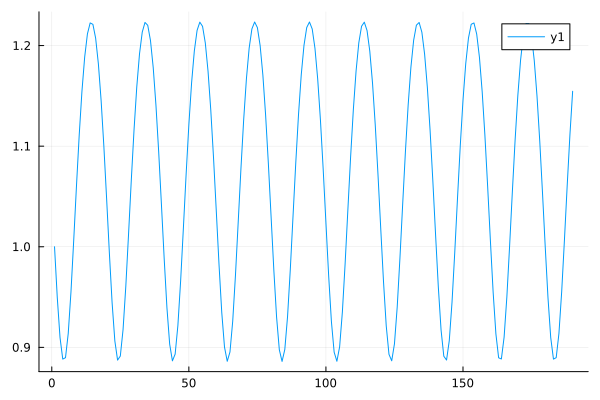

In [59]:
plot(rtraj_scaled) 

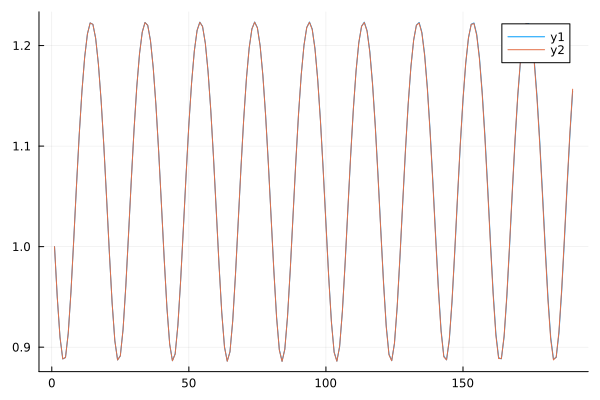

In [47]:
plot(rtraj_scaled)

#r is the norm of the position of the trajectory with control applied 
plot!(r) 

In [48]:
#r at the end of the 10 revolutions when no control is applied (in km)
rtraj_scaled[end]*position_scale 

7840.748134430562

In [49]:
#r at the end of 10 revolutions when low thrust is applied (in km)
r[end]*position_scale 

7854.476971819704

In [50]:
#at the end, r decreases by 10 km. takes 8 min to compute a solution for 10 revs.

In [51]:
#transform into matrices for plotting 
q = zeros(3, N)
v = zeros(3, N)
a = zeros(3, N)
u = zeros(3, N-1)


for i=1:N

    q[:,i] = q_vector[i]
    v[:,i] = v_vector[i]
    a[:,i] = a_vector[i]

end

for i=1:N-1

    u[:,i] = u_vector[i]
    
end

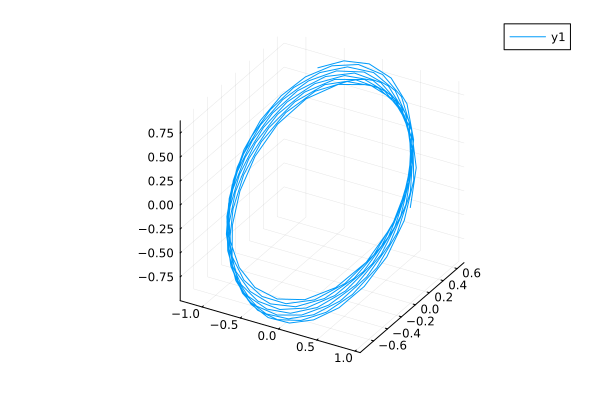

In [52]:
plot(q[1,:], q[2,:], q[3,:])

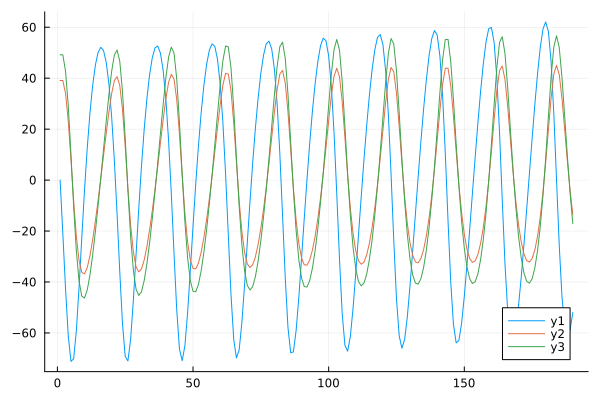

In [53]:
plot(v[1,:])
plot!(v[2,:])
plot!(v[3,:])

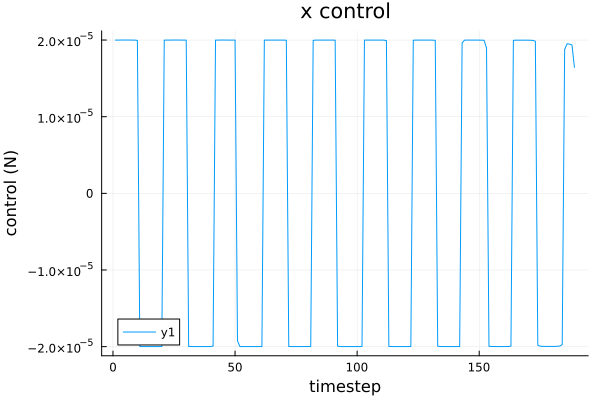

In [54]:
plot(u[1,:]*acceleration_scale*1e3, title="x control", xlabel="timestep", ylabel="control (N)")

In [61]:
u 

3×189 Matrix{Float64}:
  0.00913269   0.00913422   0.0091346   …   0.00884368   0.00751059
 -0.00913431  -0.00913427  -0.00913404     -0.00884057  -0.00661537
 -0.0091345   -0.00913447  -0.00913429     -0.00885375  -0.00745059

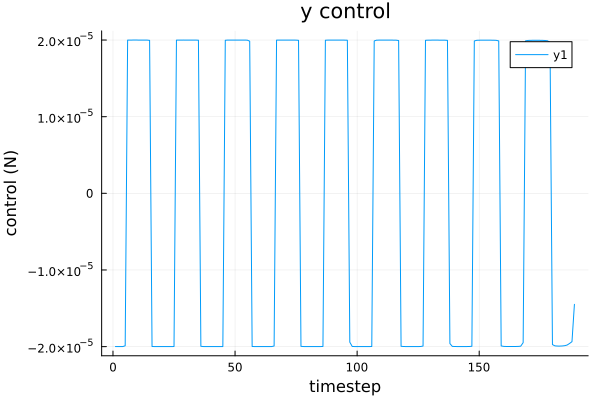

In [55]:
plot(u[2,:]*acceleration_scale*1e3, title="y control", xlabel="timestep", ylabel="control (N)")

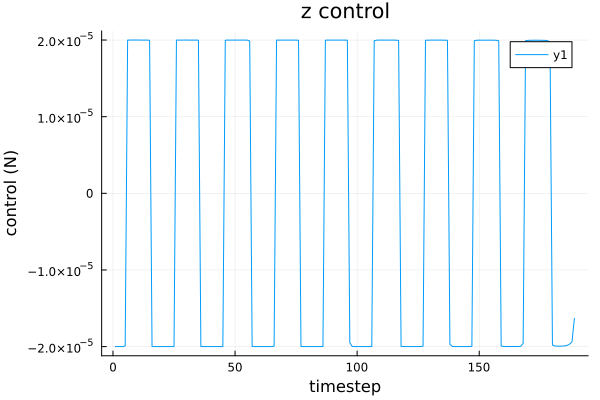

In [56]:
plot(u[3,:]*acceleration_scale*1e3, title="z control", xlabel="timestep", ylabel="control (N)") 

In [ ]:
slack_s_check = s - r.^2

In [ ]:
slack_w_check = w - r.^3 

In [ ]:
u 